# Keplerian Orbital Data Maker

Generates synthetic datasets of two-body Keplerian trajectories covering all four conic
section types: **circular**, **elliptical**, **parabolic**, and **hyperbolic**.

The primary body is treated as a **point mass** — no surface or minimum radius constraint.
Its mass is sampled over six orders of magnitude so the secondary can orbit at any
distance in the gravitational space.

| Orbit type | Eccentricity | Character |
|---|---|---|
| Circular | $e = 0$ | Bound, constant radius |
| Elliptical | $0 < e < 1$ | Bound, periodic |
| Parabolic | $e = 1$ | Marginally unbound, $\varepsilon = 0$ |
| Hyperbolic | $e > 1$ | Unbound, flyby |

All trajectories are computed **analytically** via Kepler's time–anomaly equations (no ODE integration).

In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Physical Constants

Only $G$ is fixed globally.  The primary mass $M$ is a free parameter sampled per dataset,
making the central body a generic point mass.

In [2]:
G = 6.674e-11   # gravitational constant  [m^3 kg^-1 s^-2]

## Orbit Generator — Analytical Keplerian Mechanics

### Perifocal frame

For any conic section with semi-latus rectum $p = q(1+e)$ and eccentricity $e$:

$$r(\theta) = \frac{p}{1 + e\cos\theta}, \qquad
\mathbf{r}_\mathrm{peri} = r\begin{pmatrix}\cos\theta \\ \sin\theta \\ 0\end{pmatrix}, \qquad
\mathbf{v}_\mathrm{peri} = \sqrt{\frac{\mu}{p}}\begin{pmatrix}-\sin\theta \\ e+\cos\theta \\ 0\end{pmatrix}$$

### Time from periapsis

| Orbit type | Formula |
|---|---|
| Circular / Elliptical | $t = (E - e\sin E)\,/\,n$, $\;n=\sqrt{\mu/a^3}$, $\;a=p/(1-e^2)$ |
| Parabolic | $t = \sqrt{2q^3/\mu}\,(D + D^3/3)$, $\;D=\tan(\theta/2)$ |
| Hyperbolic | $t = (e\sinh F - F)\,/\,n$, $\;n=\sqrt{\mu/a^3}$, $\;a=p/(e^2-1)$ |

### Euler rotations (perifocal → inertial)

$$\omega\ (z\text{-axis}) \;\to\; i\ (x\text{-axis}) \;\to\; \Omega\ (z\text{-axis})$$

### Conserved quantities

$$\varepsilon = \frac{v^2}{2} - \frac{\mu}{r} = \begin{cases}-\mu/(2a) & e<1\\ 0 & e=1 \\ +\mu/(2a) & e>1\end{cases}, \qquad h = |\mathbf{r}\times\mathbf{v}| = \sqrt{\mu p}$$

In [3]:
def theta_to_time(theta, mu, e, q):
    '''
    Convert true anomaly to time from periapsis for any conic section.

    Parameters
    ----------
    theta : array-like  – true anomaly [rad]
    mu    : float       – gravitational parameter G*(M+m) [m^3/s^2]
    e     : float       – eccentricity
    q     : float       – periapsis distance [m]

    Returns
    -------
    t : ndarray – time from periapsis [s]  (negative = approaching, positive = receding)
    '''
    theta = np.asarray(theta, dtype=float)
    p = q * (1.0 + e)

    if abs(e - 1.0) < 1e-10:                        # ---- parabolic
        D = np.tan(theta / 2.0)
        return np.sqrt(2.0 * q**3 / mu) * (D + D**3 / 3.0)

    elif e < 1.0:                                    # ---- circular / elliptical
        a = p / (1.0 - e**2)
        n = np.sqrt(mu / a**3)                       # mean motion [rad/s]
        k    = np.floor(theta / (2.0 * np.pi))       # integer period index
        th_w = theta - k * 2.0 * np.pi              # wrapped theta in [0, 2pi)
        # Eccentric anomaly: sin(th_w/2) >= 0 for th_w in [0,2pi) -> E_w in [0,2pi]
        E_w = 2.0 * np.arctan2(
            np.sqrt(1.0 - e) * np.sin(th_w / 2.0),
            np.sqrt(1.0 + e) * np.cos(th_w / 2.0))
        E_total = E_w + k * 2.0 * np.pi
        return (E_total - e * np.sin(E_w)) / n

    else:                                            # ---- hyperbolic
        a = p / (e**2 - 1.0)
        n = np.sqrt(mu / a**3)
        F = 2.0 * np.arctanh(
            np.sqrt((e - 1.0) / (e + 1.0)) * np.tan(theta / 2.0))
        return (e * np.sinh(F) - F) / n


def _perifocal_state(theta, mu, e, q):
    '''Position and velocity in the perifocal (P-Q) frame.'''
    p   = q * (1.0 + e)
    r   = p / (1.0 + e * np.cos(theta))
    x_p =  r * np.cos(theta)
    y_p =  r * np.sin(theta)
    fac  = np.sqrt(mu / p)
    vx_p = -fac * np.sin(theta)
    vy_p =  fac * (e + np.cos(theta))
    z_p  = np.zeros_like(theta)
    return x_p, y_p, z_p, vx_p, vy_p, z_p.copy()


def _rotate_to_inertial(x, y, z, vx, vy, vz, arg_peri, inc, raan):
    '''Euler rotations omega(z) -> i(x) -> Omega(z) : perifocal -> inertial.'''
    # 1. argument of periapsis (z-axis)
    cw, sw = np.cos(arg_peri), np.sin(arg_peri)
    x1  = cw*x  - sw*y;   vx1 = cw*vx  - sw*vy
    y1  = sw*x  + cw*y;   vy1 = sw*vx  + cw*vy
    # 2. inclination (x-axis)
    ci, si = np.cos(inc), np.sin(inc)
    x2 = x1
    y2  = ci*y1 - si*z;   vy2 = ci*vy1 - si*vz
    z2  = si*y1 + ci*z;   vz2 = si*vy1 + ci*vz
    vx2 = vx1
    # 3. RAAN (z-axis)
    cO, sO = np.cos(raan), np.sin(raan)
    xf  = cO*x2  - sO*y2;  vxf = cO*vx2 - sO*vy2
    yf  = sO*x2  + cO*y2;  vyf = sO*vx2 + cO*vy2
    return xf, yf, z2, vxf, vyf, vz2

In [4]:
def generate_keplerian_orbit(M_central, m_secondary, e, q,
                              inclination, raan, arg_peri,
                              n_points, n_periods=3, r_cutoff_factor=200,
                              orbit_type=None):
    '''
    Generate one Keplerian two-body trajectory (any conic section).

    The primary is a point mass — no surface radius, secondary can start
    anywhere and travel anywhere in the gravitational space.

    Parameters
    ----------
    M_central       : float  – primary mass [kg]        (point mass)
    m_secondary     : float  – secondary mass [kg]
    e               : float  – eccentricity
                               0          -> circular
                               (0, 1)     -> elliptical
                               1          -> parabolic
                               > 1        -> hyperbolic
    q               : float  – periapsis distance [m]
    inclination     : float  – orbital inclination [rad]
    raan            : float  – right ascension of ascending node [rad]
    arg_peri        : float  – argument of periapsis [rad]
    n_points        : int    – number of uniformly-spaced time samples
    n_periods       : int    – periods to simulate  (closed orbits only)
    r_cutoff_factor : float  – r_max = q * r_cutoff_factor  (open orbits)
    orbit_type      : str    – label stored in the returned dict

    Returns
    -------
    dict with state arrays (x, y, z, vx, vy, vz, t) and orbital metadata.
    '''
    mu = G * (M_central + m_secondary)
    p  = q * (1.0 + e)

    # ---- true anomaly range --------------------------------------------------
    if e < 1.0:                              # closed orbit
        theta_dense = np.linspace(0.0, 2.0 * np.pi * n_periods, 20 * n_points)
    else:                                    # open orbit
        r_max = q * r_cutoff_factor
        if abs(e - 1.0) < 1e-10:            # parabolic
            cos_th = float(np.clip(2.0 * q / r_max - 1.0, -1.0 + 1e-8, 1.0 - 1e-8))
        else:                               # hyperbolic
            cos_th = float(np.clip((p / r_max - 1.0) / e, -1.0 + 1e-8, 1.0 - 1e-8))
        th_lim = np.arccos(cos_th) * 0.999  # stay away from the asymptote
        theta_dense = np.linspace(-th_lim, th_lim, 20 * n_points)

    # ---- dense theta -> time, then resample uniformly in t ------------------
    t_dense = theta_to_time(theta_dense, mu, e, q)
    t       = np.linspace(t_dense[0], t_dense[-1], n_points)
    theta   = np.interp(t, t_dense, theta_dense)

    # ---- state in perifocal frame, then rotate to inertial ------------------
    xp, yp, zp, vxp, vyp, vzp = _perifocal_state(theta, mu, e, q)
    x, y, z, vx, vy, vz = _rotate_to_inertial(
        xp, yp, zp, vxp, vyp, vzp, arg_peri, inclination, raan)

    # ---- scalar metadata -----------------------------------------------------
    if e < 1.0:
        a        = p / (1.0 - e**2)
        T_period = 2.0 * np.pi * np.sqrt(a**3 / mu)
    elif abs(e - 1.0) < 1e-10:    # parabolic: no finite semi-major axis
        a        = None
        T_period = None
    else:                          # hyperbolic: semi-transverse axis (positive)
        a        = p / (e**2 - 1.0)
        T_period = None

    return dict(
        x=x, y=y, z=z, vx=vx, vy=vy, vz=vz, t=t,
        M_central=M_central, m_secondary=m_secondary, mu=mu,
        e=e, q=q, p=p,
        inclination=inclination, raan=raan, arg_peri=arg_peri,
        T_period=T_period, orbit_type=orbit_type, n_points=n_points,
    )

## Generate 1 000 Datasets

### Dataset allocation
| Type | Count | Eccentricity | Notes |
|---|---|---|---|
| Circular | 250 | $e = 0$ | |
| Elliptical | 500 | $e \in [0.01, 0.99]$ | log-biased towards high $e$ |
| Parabolic | 125 | $e = 1$ | cutoff at $r_{\max}=q\times\text{rcf}$, rcf $\in[50,500]$ |
| Hyperbolic | 125 | $e \in [1.001, 5]$ | cutoff at $r_{\max}=q\times\text{rcf}$, rcf $\in[10,200]$ |

### Shared parameter ranges
| Parameter | Range | Sampling |
|---|---|---|
| Primary mass $M$ | $10^{22}$–$2\times10^{30}$ kg | Log-uniform |
| Secondary mass $m$ | 1–$10^4$ kg | Log-uniform |
| Periapsis $q$ | $10^6$–$10^{13}$ m | Log-uniform |
| Inclination $i$ | 0°–180° | Uniform |
| RAAN $\Omega$ | 0°–360° | Uniform |
| Arg. periapsis $\omega$ | 0°–360° | Uniform |
| Points per dataset | 200–2 000 | Uniform integer |
| Periods (closed) | 1–5 | Uniform integer |

In [5]:
rng = np.random.default_rng(seed=42)

N_CIRCULAR   = 250
N_ELLIPTICAL = 500
N_PARABOLIC  = 125
N_HYPERBOLIC = 125

# ---- global parameter bounds -------------------------------------------------
M_MIN,  M_MAX   = 1e22, 2e30      # primary mass [kg]: dwarf planet -> 1 solar
MS_MIN, MS_MAX  = 1.0,  1e4      # secondary mass [kg]: 1 kg -> 10 tonne
Q_MIN,  Q_MAX   = 1e6,  1e13     # periapsis distance [m]
INC_MIN, INC_MAX = 0.0, np.pi
RA_MIN,  RA_MAX  = 0.0, 2.0 * np.pi
AP_MIN,  AP_MAX  = 0.0, 2.0 * np.pi
NP_MIN,  NP_MAX  = 200, 2000     # samples per dataset
NPR_MIN, NPR_MAX = 1,   5        # periods (closed orbits)


def _sample(n, rng):
    '''Log-uniform M, m, q plus uniform angular elements for n datasets.'''
    M  = np.exp(rng.uniform(np.log(M_MIN),  np.log(M_MAX),  n))
    ms = np.exp(rng.uniform(np.log(MS_MIN), np.log(MS_MAX), n))
    q  = np.exp(rng.uniform(np.log(Q_MIN),  np.log(Q_MAX),  n))
    return (M, ms, q,
            rng.uniform(INC_MIN, INC_MAX, n),
            rng.uniform(RA_MIN,  RA_MAX,  n),
            rng.uniform(AP_MIN,  AP_MAX,  n),
            rng.integers(NP_MIN, NP_MAX + 1, n))


datasets = []

# ---- 1. Circular (e = 0) ------------------------------------------------------
M, ms, q, inc, ra, ap, npts = _sample(N_CIRCULAR, rng)
nper = rng.integers(NPR_MIN, NPR_MAX + 1, N_CIRCULAR)
for i in range(N_CIRCULAR):
    ds = generate_keplerian_orbit(
        M[i], ms[i], 0.0, q[i], inc[i], ra[i], ap[i],
        int(npts[i]), n_periods=int(nper[i]), orbit_type='circular')
    ds['dataset_id'] = len(datasets)
    datasets.append(ds)

# ---- 2. Elliptical (0.01 <= e <= 0.99) ----------------------------------------
M, ms, q, inc, ra, ap, npts = _sample(N_ELLIPTICAL, rng)
e_ell = rng.uniform(0.01, 0.99, N_ELLIPTICAL)
nper  = rng.integers(NPR_MIN, NPR_MAX + 1, N_ELLIPTICAL)
for i in range(N_ELLIPTICAL):
    ds = generate_keplerian_orbit(
        M[i], ms[i], e_ell[i], q[i], inc[i], ra[i], ap[i],
        int(npts[i]), n_periods=int(nper[i]), orbit_type='elliptical')
    ds['dataset_id'] = len(datasets)
    datasets.append(ds)

# ---- 3. Parabolic (e = 1 exactly) ---------------------------------------------
M, ms, q, inc, ra, ap, npts = _sample(N_PARABOLIC, rng)
rcf_par = rng.uniform(50.0, 500.0, N_PARABOLIC)
for i in range(N_PARABOLIC):
    ds = generate_keplerian_orbit(
        M[i], ms[i], 1.0, q[i], inc[i], ra[i], ap[i],
        int(npts[i]), r_cutoff_factor=rcf_par[i], orbit_type='parabolic')
    ds['dataset_id'] = len(datasets)
    datasets.append(ds)

# ---- 4. Hyperbolic (1.001 <= e <= 5.0) ----------------------------------------
M, ms, q, inc, ra, ap, npts = _sample(N_HYPERBOLIC, rng)
e_hyp   = rng.uniform(1.001, 5.0, N_HYPERBOLIC)
rcf_hyp = rng.uniform(10.0, 200.0, N_HYPERBOLIC)
for i in range(N_HYPERBOLIC):
    ds = generate_keplerian_orbit(
        M[i], ms[i], e_hyp[i], q[i], inc[i], ra[i], ap[i],
        int(npts[i]), r_cutoff_factor=rcf_hyp[i], orbit_type='hyperbolic')
    ds['dataset_id'] = len(datasets)
    datasets.append(ds)

# ---- summary ------------------------------------------------------------------
print(f'Generated {len(datasets)} datasets\n')
print(f'{"Type":<14}  {"Count":>6}  {"Total pts":>10}  '
      f'{"e min":>7}  {"e max":>7}  {"q min [km]":>12}  {"q max [km]":>12}')
print('-' * 82)
for otype in ('circular', 'elliptical', 'parabolic', 'hyperbolic'):
    sub   = [d for d in datasets if d['orbit_type'] == otype]
    e_arr = [d['e'] for d in sub]
    q_arr = [d['q'] / 1e3 for d in sub]
    total = sum(d['n_points'] for d in sub)
    print(f'{otype:<14}  {len(sub):>6}  {total:>10,}  '
          f'{min(e_arr):>7.4f}  {max(e_arr):>7.4f}  '
          f'{min(q_arr):>12.3g}  {max(q_arr):>12.3g}')

Generated 1000 datasets

Type             Count   Total pts    e min    e max    q min [km]    q max [km]
----------------------------------------------------------------------------------
circular           250     277,909   0.0000   0.0000      1.02e+03       9.8e+09
elliptical         500     551,441   0.0103   0.9889      1.01e+03       9.9e+09
parabolic          125     127,239   1.0000   1.0000      1.01e+03      9.48e+09
hyperbolic         125     133,578   1.0297   4.9926      1.02e+03      8.07e+09


## Verification

For any Keplerian orbit two quantities are strictly conserved along the trajectory:

1. **Specific orbital energy** $\varepsilon = v^2/2 - \mu/r$
   - Circular/elliptical: $\varepsilon = -\mu/(2a)$
   - Parabolic: $\varepsilon = 0$
   - Hyperbolic: $\varepsilon = +\mu/(2a)$
2. **Specific angular momentum magnitude** $h = |\mathbf{r}\times\mathbf{v}| = \sqrt{\mu p}$

All errors below should be at floating-point machine precision ($\lesssim 10^{-12}$).

In [6]:
max_eps_err   = 0.0   # worst relative energy error (non-parabolic)
max_h_err     = 0.0   # worst relative angular momentum error
par_eps_max   = 0.0   # max |eps| normalised by mu/p  (should be ~0 for parabolic)

for ds in datasets:
    mu = ds['mu']
    e  = ds['e']
    p  = ds['p']

    r  = np.sqrt(ds['x']**2 + ds['y']**2 + ds['z']**2)
    v2 = ds['vx']**2 + ds['vy']**2 + ds['vz']**2

    # specific orbital energy
    eps = 0.5 * v2 - mu / r

    # specific angular momentum magnitude
    Lx = ds['y']*ds['vz'] - ds['z']*ds['vy']
    Ly = ds['z']*ds['vx'] - ds['x']*ds['vz']
    Lz = ds['x']*ds['vy'] - ds['y']*ds['vx']
    h  = np.sqrt(Lx**2 + Ly**2 + Lz**2)
    h_expected = np.sqrt(mu * p)

    if abs(e - 1.0) < 1e-10:            # parabolic -> eps should be ~0
        par_eps_max = max(par_eps_max, np.max(np.abs(eps)) / (mu / p))
    else:
        a = p / abs(1.0 - e**2)
        eps_expected = (-1.0 if e < 1.0 else 1.0) * mu / (2.0 * a)
        rel = np.max(np.abs(eps - eps_expected)) / abs(eps_expected)
        max_eps_err = max(max_eps_err, rel)

    max_h_err = max(max_h_err,
                    np.max(np.abs(h - h_expected)) / h_expected)

print('Conservation law verification (all 1000 datasets, all orbit types):')
print(f'  Specific energy  (circ / ell / hyp) : {max_eps_err:.2e}  max relative error')
print(f'  Specific energy  (parabolic |eps|/(mu/p)) : {par_eps_max:.2e}')
print(f'  Angular momentum magnitude          : {max_h_err:.2e}  max relative error')

Conservation law verification (all 1000 datasets, all orbit types):
  Specific energy  (circ / ell / hyp) : 4.31e-14  max relative error
  Specific energy  (parabolic |eps|/(mu/p)) : 1.17e-15
  Angular momentum magnitude          : 3.59e-14  max relative error


## Quick Visualisation — Two Examples of Each Orbit Type

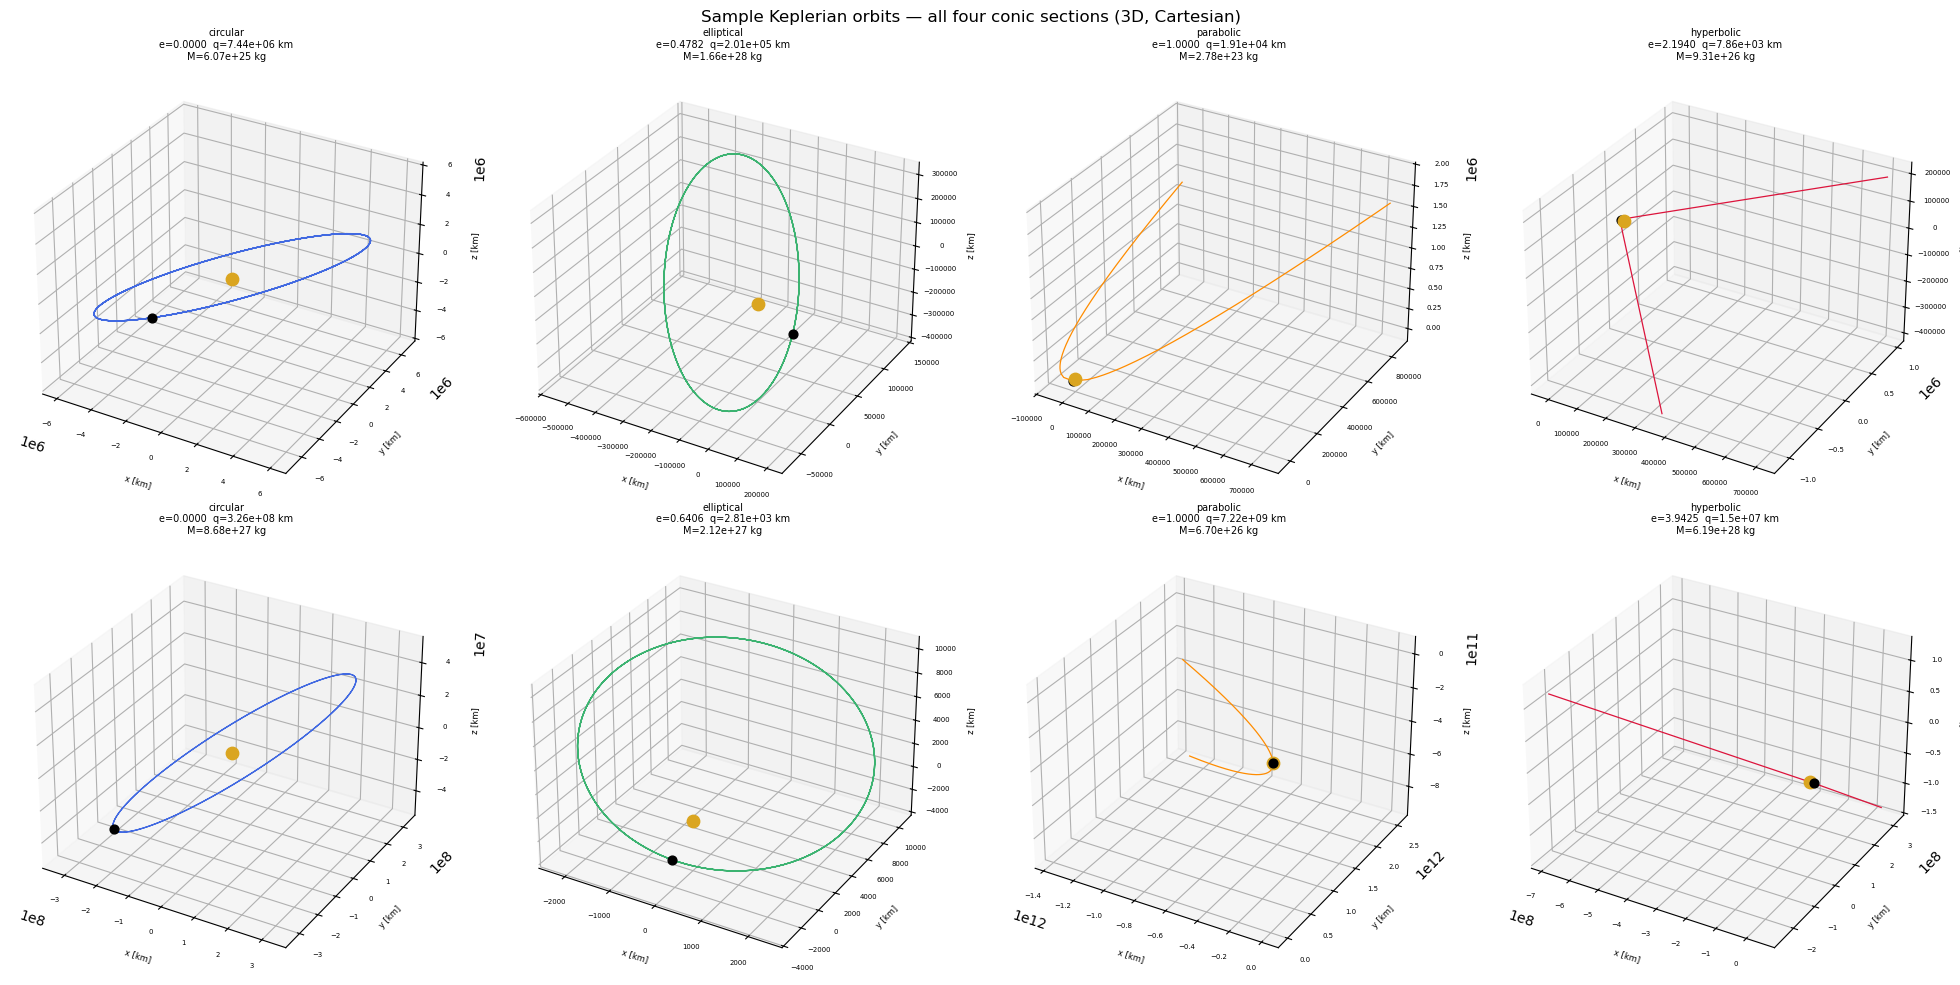

In [7]:
orbit_types = ('circular', 'elliptical', 'parabolic', 'hyperbolic')
clrs = {'circular':   'royalblue',
        'elliptical': 'mediumseagreen',
        'parabolic':  'darkorange',
        'hyperbolic': 'crimson'}

type_buckets = {ot: [d for d in datasets if d['orbit_type'] == ot]
                for ot in orbit_types}

fig = plt.figure(figsize=(20, 10))
for col, otype in enumerate(orbit_types):
    bucket = type_buckets[otype]
    picks  = rng.choice(len(bucket), size=2, replace=False)
    for row, idx in enumerate(picks):
        ds  = bucket[idx]
        ax  = fig.add_subplot(2, 4, row * 4 + col + 1, projection='3d')
        sc  = 1e-3   # m -> km
        ax.plot(ds['x']*sc, ds['y']*sc, ds['z']*sc,
                lw=0.9, color=clrs[otype])
        ax.scatter([0], [0], [0], c='goldenrod', s=80, zorder=5, label='primary')
        # mark periapsis
        r  = np.sqrt(ds['x']**2 + ds['y']**2 + ds['z']**2)
        pi = int(np.argmin(r))
        ax.scatter([ds['x'][pi]*sc], [ds['y'][pi]*sc], [ds['z'][pi]*sc],
                   c='k', s=40, zorder=6)
        ax.set_title(
            f'{otype}\ne={ds["e"]:.4f}  q={ds["q"]/1e3:.3g} km\n'
            f'M={ds["M_central"]:.2e} kg',
            fontsize=7)
        ax.set_xlabel('x [km]', fontsize=6)
        ax.set_ylabel('y [km]', fontsize=6)
        ax.set_zlabel('z [km]', fontsize=6)
        ax.tick_params(labelsize=5)

plt.suptitle('Sample Keplerian orbits — all four conic sections (3D, Cartesian)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Aggregate Statistics Across All Datasets

In [8]:
CHANNELS = ('x', 'y', 'z', 'vx', 'vy', 'vz', 't')
all_ch   = {ch: np.concatenate([d[ch] for d in datasets]) for ch in CHANNELS}

total_pts = len(all_ch['t'])
all_r = np.sqrt(all_ch['x']**2 + all_ch['y']**2 + all_ch['z']**2)
all_v = np.sqrt(all_ch['vx']**2 + all_ch['vy']**2 + all_ch['vz']**2)

print(f'Total data points (all datasets): {total_pts:,}\n')
print(f'{"Quantity":<8}  {"Unit":<5}  {"Min":>12}  {"Mean":>12}  '
      f'{"Std Dev":>12}  {"Max":>12}')
print('-' * 66)
for label, arr, unit in [
        ("|r|",  all_r,        'm'),
        ("|v|",  all_v,        'm/s'),
        ('t',    all_ch['t'],  's')]:
    print(f'{label:<8}  {unit:<5}  {arr.min():>12.3e}  {arr.mean():>12.3e}  '
          f'{arr.std():>12.3e}  {arr.max():>12.3e}')

print()

# ---- pooled component stats (useful for PINN normalisation) -----------------
pos_pool = np.concatenate([all_ch['x'], all_ch['y'], all_ch['z']])
vel_pool = np.concatenate([all_ch['vx'], all_ch['vy'], all_ch['vz']])

pooled_stats = {
    'pos': {'mean': pos_pool.mean(), 'std': pos_pool.std()},
    'vel': {'mean': vel_pool.mean(), 'std': vel_pool.std()},
    't':   {'mean': all_ch['t'].mean(), 'std': all_ch['t'].std()},
}

print(f'{"Channel":<10}  {"Unit":<5}  {"Pooled mean":>14}  {"Pooled std":>14}')
print('-' * 50)
for ch, unit in [('pos', 'm'), ('vel', 'm/s'), ('t', 's')]:
    s = pooled_stats[ch]
    print(f'{ch:<10}  {unit:<5}  {s["mean"]:>14.4e}  {s["std"]:>14.4e}')

Total data points (all datasets): 1,090,167

Quantity  Unit            Min          Mean       Std Dev           Max
------------------------------------------------------------------
|r|       m         1.007e+06     2.037e+13     1.415e+14     3.913e+15
|v|       m/s       4.117e-02     1.104e+05     4.915e+05     1.024e+07
t         s        -4.761e+16     4.822e+12     8.476e+14     4.761e+16

Channel     Unit      Pooled mean      Pooled std
--------------------------------------------------
pos         m          1.5496e+12      8.2511e+13
vel         m/s        1.1225e+03      2.9082e+05
t           s          4.8218e+12      8.4758e+14


## Histograms — Distribution of Position, Speed, and Time

Position and speed span many orders of magnitude across all orbit types, so $\log_{10}$ scaling is used.

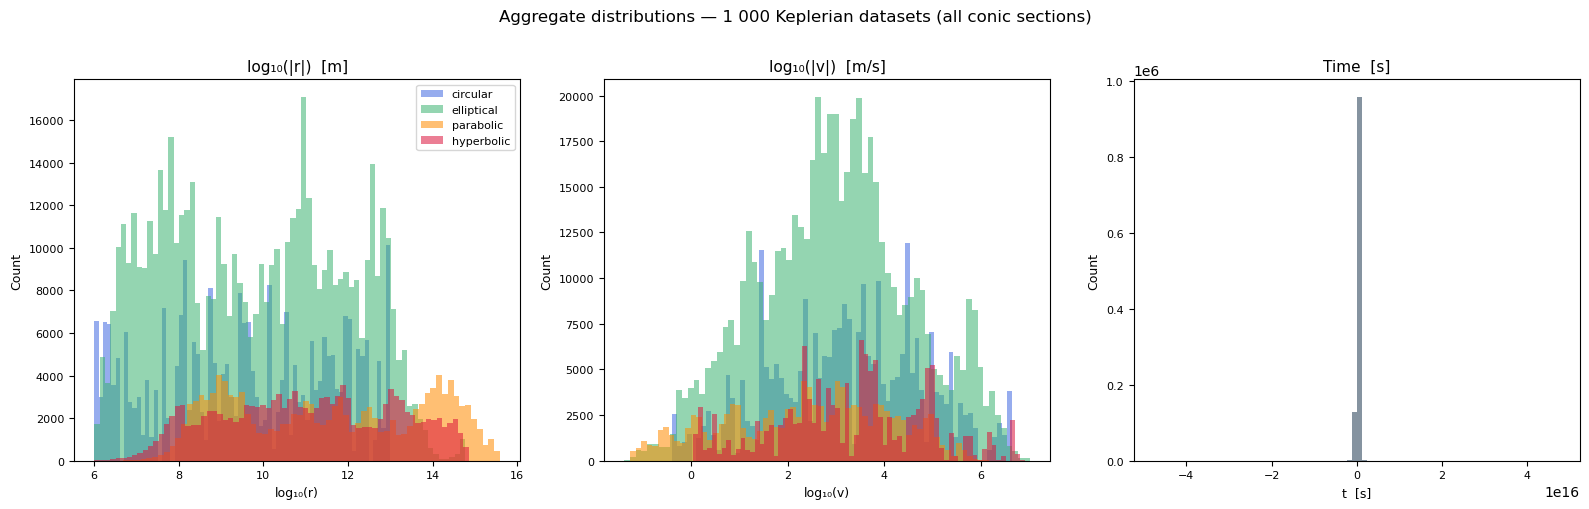

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
orbit_types_list = ('circular', 'elliptical', 'parabolic', 'hyperbolic')
clrs2 = {'circular':   'royalblue',
         'elliptical': 'mediumseagreen',
         'parabolic':  'darkorange',
         'hyperbolic': 'crimson'}

for otype in orbit_types_list:
    sub = [d for d in datasets if d['orbit_type'] == otype]
    xs  = np.concatenate([d['x']  for d in sub])
    ys  = np.concatenate([d['y']  for d in sub])
    zs  = np.concatenate([d['z']  for d in sub])
    r_s = np.sqrt(xs**2 + ys**2 + zs**2)
    vxs = np.concatenate([d['vx'] for d in sub])
    vys = np.concatenate([d['vy'] for d in sub])
    vzs = np.concatenate([d['vz'] for d in sub])
    v_s = np.sqrt(vxs**2 + vys**2 + vzs**2)
    axes[0].hist(np.log10(r_s),         bins=70, color=clrs2[otype], alpha=0.55, label=otype)
    axes[1].hist(np.log10(v_s[v_s>0]),  bins=70, color=clrs2[otype], alpha=0.55)

for ax, title, xl in zip(axes[:2],
                         ['log\u2081\u2080(|r|)  [m]', 'log\u2081\u2080(|v|)  [m/s]'],
                         ['log\u2081\u2080(r)', 'log\u2081\u2080(v)']):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)
axes[0].legend(fontsize=8)

axes[2].hist(all_ch['t'], bins=80, color='slategray', alpha=0.85)
axes[2].set_title('Time  [s]', fontsize=11)
axes[2].set_xlabel('t  [s]', fontsize=9)
axes[2].set_ylabel('Count', fontsize=9)
axes[2].tick_params(labelsize=8)

plt.suptitle('Aggregate distributions — 1 000 Keplerian datasets (all conic sections)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Save Datasets to Disk

Two formats are written:
- **Pickle** — full list of dicts; preserves variable-length arrays and string fields.
- **NPZ** — flat compressed archive; each channel keyed as `x_0000`, `x_0001`, …

In [10]:
OUTPUT_DIR = 'data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- pickle (full dicts) -------------------------------------------------------
pkl_path = os.path.join(OUTPUT_DIR, 'keplerian_orbit_datasets.pkl')
with open(pkl_path, 'wb') as fh:
    pickle.dump(datasets, fh)
print(f'Saved pickle  -> {pkl_path}')

# ---- npz (flat arrays, 4-digit index) -----------------------------------------
ARRAY_KEYS  = ('x', 'y', 'z', 'vx', 'vy', 'vz', 't')
SCALAR_KEYS = ('M_central', 'm_secondary', 'mu', 'e', 'q', 'p',
               'inclination', 'raan', 'arg_peri', 'n_points')

npz_dict = {}
for ds in datasets:
    tag = f'{ds["dataset_id"]:04d}'
    for key in ARRAY_KEYS:
        npz_dict[f'{key}_{tag}'] = ds[key]
    for key in SCALAR_KEYS:
        npz_dict[f'{key}_{tag}'] = np.array([ds[key]])
    npz_dict[f'orbit_type_{tag}'] = np.array([ds['orbit_type']], dtype='U12')

npz_path = os.path.join(OUTPUT_DIR, 'keplerian_orbit_datasets.npz')
np.savez_compressed(npz_path, **npz_dict)
print(f'Saved npz     -> {npz_path}')
print(f'\nTotal datasets : {len(datasets)}')
print(f'Total points   : {sum(d["n_points"] for d in datasets):,}')

Saved pickle  -> data/keplerian_orbit_datasets.pkl
Saved npz     -> data/keplerian_orbit_datasets.npz

Total datasets : 1000
Total points   : 1,090,167


## Loading the Data (reference snippet)

```python
import pickle, numpy as np

# Option A – pickle (recommended for downstream PINN notebooks)
with open('data/keplerian_orbit_datasets.pkl', 'rb') as fh:
    datasets = pickle.load(fh)

ds = datasets[0]
# Keys: x, y, z, vx, vy, vz, t, orbit_type, e, q, p, mu,
#       M_central, m_secondary, inclination, raan, arg_peri,
#       T_period (None for open orbits), n_points, dataset_id

# Option B – npz (index-based access)
data  = np.load('data/keplerian_orbit_datasets.npz')
x0    = data['x_0000']             # x-coordinates of dataset 0
t0    = data['t_0000']
otype = str(data['orbit_type_0000'][0])   # e.g. 'circular'
```

### PINN normalisation hint

Positions and speeds span ~7 orders of magnitude across the full dataset.  Consider
normalising with log-scale or per-dataset scaling:

```python
q  = ds['q']                  # periapsis [m]
mu = ds['mu']                 # gravitational parameter
v0 = np.sqrt(mu / q)         # characteristic speed at periapsis
t0 = np.sqrt(q**3 / mu)      # dynamical time scale

x_norm  = ds['x']  / q
v_norm  = ds['vx'] / v0
t_norm  = ds['t']  / t0
```